In [1]:
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\geova\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Importando as bibliotecas
import pandas as pd

# Carregando a base de dados
base_dados = pd.read_csv('br_inpe_prodes_municipio_bioma.csv', sep = ';', decimal=',')# Visualizando as primeiras linhas da base
df = base_dados

In [3]:
base_dados = pd.read_csv('br_inpe_prodes_municipio_bioma.csv', sep=',')
print(base_dados.columns)
print(base_dados.dtypes)

Index(['ano', 'id_municipio', 'bioma', 'area_total', 'desmatado',
       'vegetacao_natural', 'nao_vegetacao_natural', 'hidrografia'],
      dtype='str')
ano                        int64
id_municipio               int64
bioma                        str
area_total               float64
desmatado                float64
vegetacao_natural        float64
nao_vegetacao_natural    float64
hidrografia              float64
dtype: object


In [4]:
print(base_dados.head())

    ano  id_municipio     bioma   area_total  desmatado  vegetacao_natural  \
0  2009       5102504  Pantanal  17422.29079     3124.8            12616.5   
1  2011       5102504  Pantanal  17422.29079     3203.4            12537.9   
2  2010       5102504  Pantanal  17422.29079     3157.8            12583.5   
3  2005       5102504  Pantanal  17422.29079     2937.1            12804.2   
4  2002       5102504  Pantanal  17422.29079     2598.0            13143.3   

   nao_vegetacao_natural  hidrografia  
0                    0.4       1680.6  
1                    0.4       1680.6  
2                    0.4       1680.6  
3                    0.4       1680.6  
4                    0.4       1680.6  


In [5]:
print(base_dados.shape)

(156864, 8)


### Verificar se soma das partes (desmatado + vegetacao_natural + nao_vegetacao_natural + hidrografia) bate com a area_total

In [6]:
# Criando uma coluna de verificação
base_dados['soma_partes'] = (base_dados['desmatado'] + 
                             base_dados['vegetacao_natural'] + 
                             base_dados['nao_vegetacao_natural'] + 
                             base_dados['hidrografia'])

# Calculando a diferença percentual
base_dados['diferenca_area'] = abs(base_dados['area_total'] - base_dados['soma_partes']) / base_dados['area_total']

# Filtrando apenas o que é confiável (tolerância de 1% de erro de arredondamento)
base_dados_limpos = base_dados[base_dados['diferenca_area'] < 0.01].copy()

print(f"Linhas removidas por inconsistência de área: {len(base_dados) - len(base_dados_limpos)}")

Linhas removidas por inconsistência de área: 1536


#### Verificando dados nulos

In [9]:
# Remove todas as linhas que possuem qualquer valor vazio (NaN)
df = df.dropna().reset_index(drop=True)

# Confirma se limpou tudo
print(df.isnull().sum())

ano,id_municipio,bioma,area_total,desmatado,vegetacao_natural,nao_vegetacao_natural,hidrografia    0
dtype: int64


In [12]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.1 MB ? e


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\geova\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### tabela de estatísticas descritivas

In [20]:
# Gerando as estatísticas básicas da sua base PRODES
estatisticas = df.describe()

# Exibindo de forma organizada
print("# Estatísticas básicas")
print(estatisticas)

# Estatísticas básicas
                 ano  id_municipio     area_total      desmatado  \
count  155328.000000  1.553280e+05  155328.000000  155328.000000   
mean     2011.500000  3.278326e+06    1312.630629     430.978967   
std         6.922209  9.763250e+05    5184.122406     762.497745   
min      2000.000000  1.100015e+06       0.596270       0.000000   
25%      2005.750000  2.600807e+06     160.095580      93.300000   
50%      2011.500000  3.150654e+06     340.191890     197.700000   
75%      2017.250000  4.120532e+06     857.608857     437.000000   
max      2023.000000  5.300108e+06  159482.273990   21299.100000   

       vegetacao_natural  nao_vegetacao_natural    hidrografia    soma_partes  \
count      155328.000000          155328.000000  155328.000000  155328.000000   
mean          816.241181              43.784904      21.625340    1312.630392   
std          4599.130991             441.871645     155.719787    5184.122212   
min           -17.200000               0

### Histograma

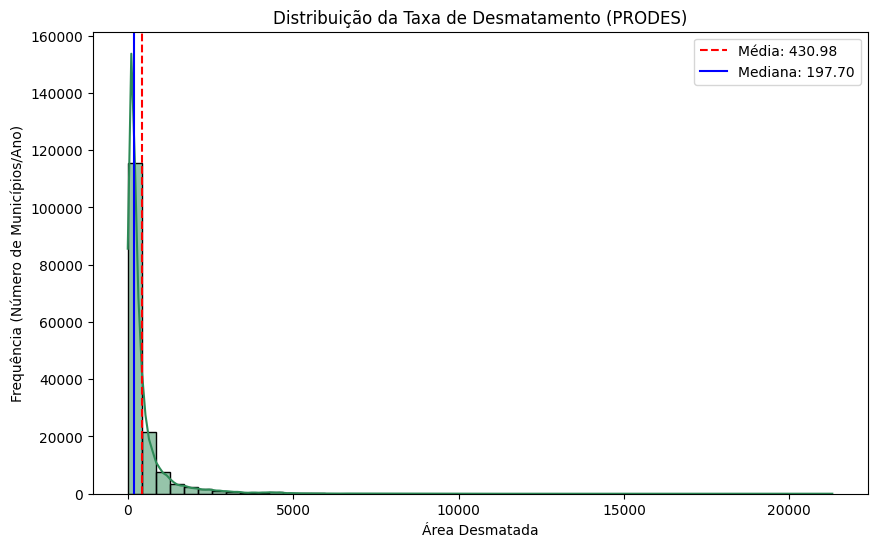

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Criando o histograma
# bins=50 divide os dados em 50 barras para dar mais detalhe
# kde=True adiciona a linha da "curva" de densidade
sns.histplot(df['desmatado'], bins=50, kde=True, color='seagreen')

# Adicionando linhas de referência que ajudam na interpretação
plt.axvline(df['desmatado'].mean(), color='red', linestyle='--', label=f"Média: {df['desmatado'].mean():.2f}")
plt.axvline(df['desmatado'].median(), color='blue', linestyle='-', label=f"Mediana: {df['desmatado'].median():.2f}")

plt.title('Distribuição da Taxa de Desmatamento (PRODES)')
plt.xlabel('Área Desmatada')
plt.ylabel('Frequência (Número de Municípios/Ano)')
plt.legend()

plt.show()

### Visualização com Boxplot

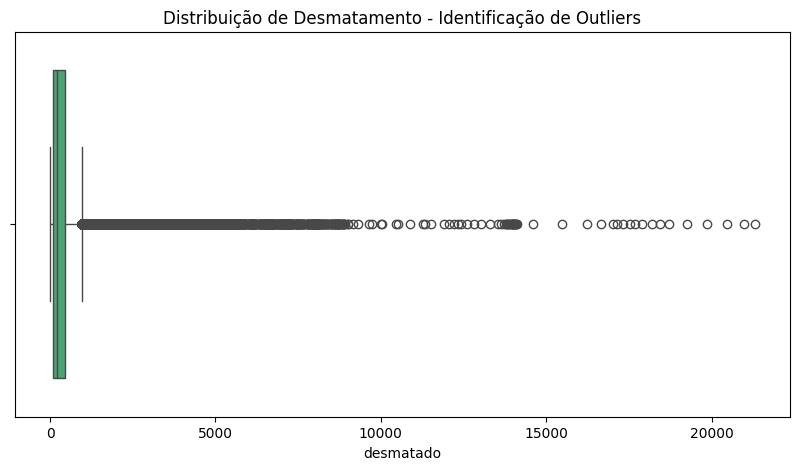

Municípios/Anos que são outliers: 3326
   id_municipio   ano  desmatado
0       5102504  2009     3124.8
1       5102504  2011     3203.4
2       5102504  2010     3157.8
3       5102504  2005     2937.1
5       5102504  2004     2869.4


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot para ver a distribuição
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['desmatado'], color='mediumseagreen')
plt.title('Distribuição de Desmatamento - Identificação de Outliers')
plt.show()

# Listando os maiores casos (Outliers)
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df['desmatado']))
outliers = df[z_scores > 3]

print(f"Municípios/Anos que são outliers: {len(outliers)}")
# Usando o nome correto da coluna 'id_municipio'
print(outliers[['id_municipio', 'ano', 'desmatado']].head())

### IQR

In [19]:
# 1. Calculando as métricas do IQR
Q1 = df['desmatado'].quantile(0.25)
Q3 = df['desmatado'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 2. Filtrando a base para encontrar os registros considerados outliers
tabela_iqr = df[df['desmatado'] > limite_superior][['id_municipio', 'ano', 'desmatado']].copy()

# 3. Adicionando uma coluna para mostrar o quanto cada um ultrapassa o limite
tabela_iqr['excesso_sobre_limite'] = tabela_iqr['desmatado'] - limite_superior

# 4. Ordenando pelos maiores valores
tabela_iqr = tabela_iqr.sort_values(by='desmatado', ascending=False)

# Exibindo os resultados
print(f"--- Métricas do IQR ---")
print(f"Q1 (25%): {Q1:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite Superior (Q3 + 1.5*IQR): {limite_superior:.2f}")
print(f"-----------------------\n")
print(f"Total de registros acima do limite: {len(tabela_iqr)}")
print("\nTop 15 registros na zona de Outliers (IQR):")
print(tabela_iqr.head(15).to_string(index=False))

--- Métricas do IQR ---
Q1 (25%): 93.30
Q3 (75%): 437.00
IQR: 343.70
Limite Superior (Q3 + 1.5*IQR): 952.55
-----------------------

Total de registros acima do limite: 16135

Top 15 registros na zona de Outliers (IQR):
 id_municipio  ano  desmatado  excesso_sobre_limite
      1507300 2023    21299.1              20346.55
      1507300 2022    20984.9              20032.35
      1507300 2021    20450.4              19497.85
      1507300 2020    19873.4              18920.85
      1507300 2019    19264.6              18312.05
      1507300 2018    18719.7              17767.15
      1507300 2017    18442.6              17490.05
      1507300 2016    18205.9              17253.35
      1507300 2015    17891.0              16938.45
      1507300 2014    17691.6              16739.05
      1507300 2013    17538.8              16586.25
      1507300 2012    17317.5              16364.95
      1507300 2011    17149.8              16197.25
      1507300 2010    17010.4              16057.85


In [18]:
from scipy import stats
import numpy as np

# 1. Calculando o Z-score
df['z_score_desmatado'] = stats.zscore(df['desmatado'])

# 2. Criando a tabela de outliers (Z > 3) ordenada do maior para o menor
tabela_outliers = df[df['z_score_desmatado'] > 3][['id_municipio', 'ano', 'desmatado', 'z_score_desmatado']]
tabela_outliers = tabela_outliers.sort_values(by='z_score_desmatado', ascending=False)

# 3. Exibindo os 10 casos mais críticos
print("Tabela de Outliers Extremos (Z > 3):")
print(tabela_outliers.head(10))

# 4. Resumo estatístico para o seu relatório
print(f"\nTotal de registros na base: {len(df)}")
print(f"Total de outliers identificados: {len(tabela_outliers)}")

Tabela de Outliers Extremos (Z > 3):
       id_municipio   ano  desmatado  z_score_desmatado
80877       1507300  2023    21299.1          27.368197
80860       1507300  2022    20984.9          26.956128
80872       1507300  2021    20450.4          26.255141
80862       1507300  2020    19873.4          25.498415
80873       1507300  2019    19264.6          24.699983
80867       1507300  2018    18719.7          23.985356
80869       1507300  2017    18442.6          23.621944
80856       1507300  2016    18205.9          23.311516
80868       1507300  2015    17891.0          22.898530
80859       1507300  2014    17691.6          22.637020

Total de registros na base: 155328
Total de outliers identificados: 3326


In [15]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\geova\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Usando log nos Outliers

In [24]:
import numpy as np

# Aplicando log (somamos 1 para evitar erro se houver valor zero)
df['desmatado_log'] = np.log1p(df['desmatado'])

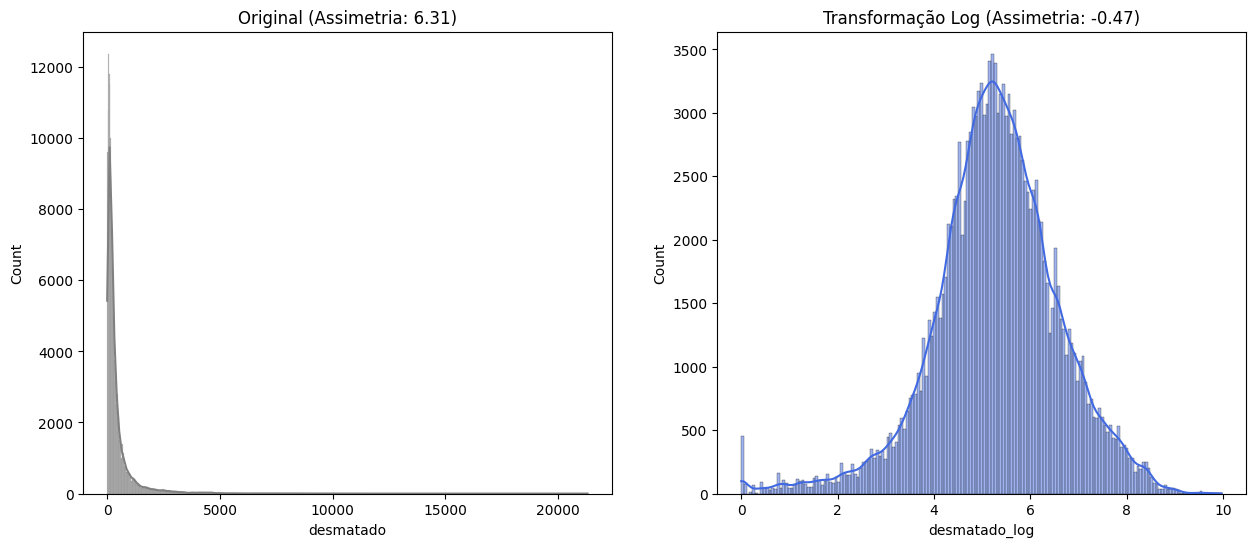

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Criando a figura para comparação
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Dados Originais
sns.histplot(df['desmatado'], kde=True, ax=ax1, color='gray')
ax1.set_title(f'Original (Assimetria: {df["desmatado"].skew():.2f})')

# Gráfico 2: Dados com Log
# Usamos log1p para evitar erro com valores zero (log(1+x))
df['desmatado_log'] = np.log1p(df['desmatado'])
sns.histplot(df['desmatado_log'], kde=True, ax=ax2, color='royalblue')
ax2.set_title(f'Transformação Log (Assimetria: {df["desmatado_log"].skew():.2f})')

plt.show()

In [26]:
from scipy import stats

# Calculando o novo Z-score sobre a coluna logarítmica
z_score_log = np.abs(stats.zscore(df['desmatado_log']))

print(f"Z-score Máximo Original: 27.36")
print(f"Z-score Máximo após Log: {z_score_log.max():.2f}")

# Contando quantos outliers restaram (Z > 3) na escala log
outliers_restantes = len(df[z_score_log > 3])
print(f"Municípios que ainda são outliers (Z > 3) no Log: {outliers_restantes}")

Z-score Máximo Original: 27.36
Z-score Máximo após Log: 4.02
Municípios que ainda são outliers (Z > 3) no Log: 1864


### Prepararando a variável dependente (o Grupo 0 e 1) e as independentes

In [27]:
# 1. Corrigindo o nome da variável e limpando nulos
df = base_dados_limpos.dropna().reset_index(drop=True)

# 2. Criando a variável dependente baseada na média de desmatamento
media_desm = df['desmatado'].mean()
df['status_critico'] = (df['desmatado'] > media_desm).astype(int)

print(f"Média de desmatamento: {media_desm:.2f}")
print(df['status_critico'].value_counts())

Média de desmatamento: 430.98
status_critico
0    115826
1     39502
Name: count, dtype: int64
